In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
tf.__version__

'2.11.0'

In [3]:
keras.__version__

'2.11.0'

# TRAIN SET / TEST SET Split

## keras

### .datasets.fashion_mnist

In [4]:
fashion_mnist = keras.datasets.fashion_mnist

#### .load_data()

In [5]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

- Each ***input is a 28x28 image***, converted into an ***array of 28x28*** whose ***values ranges from 0-255***

In [6]:
X_train_full 

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [7]:
X_train_full.shape

(60000, 28, 28)

- There are ***10 classes represented as integers*** (multiclass, 0-9)

In [8]:
y_train_full 

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [9]:
y_train_full.shape

(60000,)

# VALIDATION SET Split (from Train Set)

In [10]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0

In [11]:
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [12]:
X_train.shape

(55000, 28, 28)

In [13]:
y_train

array([4, 0, 7, ..., 3, 0, 5], dtype=uint8)

# Class names

In [14]:
class_names = ["T-shirt/top", 
               "Trouser", 
               "Pullover", 
               "Dress", 
               "Coat",
               "Sandal", 
               "Shirt", 
               "Sneaker", 
               "Bag", 
               "Ankle boot"]

# Model Building and Training

## keras.models.Sequential()

In [15]:
model = keras.models.Sequential()

### .add()

In [16]:
import warnings
warnings.filterwarnings("ignore")

model.add(keras.layers.Flatten(
    input_shape = [28, 28])
    )
model.add(keras.layers.Dense(
    units = 300, 
    activation = "relu")
    )
model.add(keras.layers.Dense(
    units = 100, 
    activation = "relu")
    )
model.add(keras.layers.Dense(
    units = 10, 
    activation = "softmax")
    )

### .summary()

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


### .compile()

In [56]:
model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(), # "sparse_categorical_crossentropy"
              optimizer = "sgd",
              metrics = ["accuracy"])

### .fit() - TRAIN SET and VALIDATION SET

In [ ]:
history = model.fit(X_train, 
                    y_train, 
                    epochs = 30, 
                    validation_data = (X_valid, y_valid))
history

#### .history

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)
history_df

,loss,accuracy,val_loss,val_accuracy
0,0.711474,0.764927,0.496795,0.8334
1,0.487729,0.830727,0.443944,0.8500
2,0.442445,0.844255,0.421680,0.8560
3,0.414287,0.853836,0.410037,0.8552
4,0.393178,0.861782,0.391789,0.8640
5,0.377897,0.867382,0.376367,0.8718
6,0.363855,0.872400,0.359051,0.8718
7,0.354175,0.874418,0.351001,0.8746
8,0.343229,0.878636,0.364388,0.8730
9,0.333436,0.880000,0.342382,0.8746


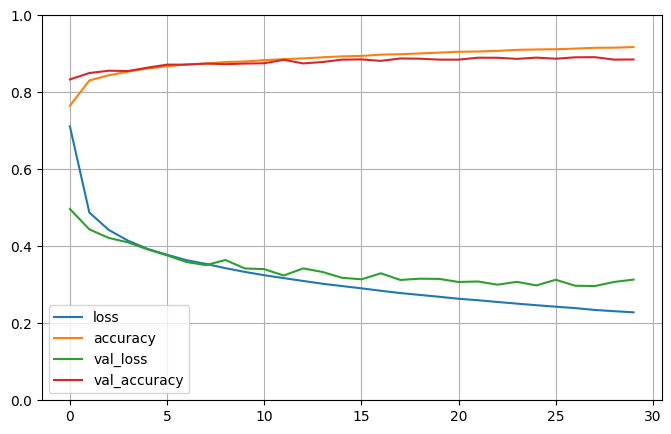

In [25]:
history_df.plot(figsize = (8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # y-axis values ranges from 0-1
plt.show()

### .evaluate() - TEST SET

In [26]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 61.2947 - accuracy: 0.8506


[61.29473114013672, 0.850600004196167]

### .predict()

In [27]:
X_sample = X_test[:3]
X_sample

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint8)

In [28]:
X_sample.shape

(3, 28, 28)

- The output is ***Categorical Cross-Entropy*** (the ***output is One-Hot encoded***)

In [30]:
y_proba = model.predict(X_sample) 
y_proba

1/1 [==============================] - 0s 74ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

### .predict_classes()

In [31]:
import numpy as np

y_pred = model.predict(X_sample)
y_pred

1/1 [==============================] - 0s 22ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [32]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_pred_classes

array([9, 2, 1], dtype=int64)

In [33]:
np.array(class_names)[y_pred_classes]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

# Model Management

## SAVE Model

### Save ENTIRE MODEL (architecture + weights)

In [ ]:
model.save(filepath = f'models/outfit_classifier.keras',
           overwrite = True,
           include_optimizer = True)

[TIP] Next time specify overwrite=True!


In [38]:
model.save(filepath = "models/outfit_classifier.h5",
           overwrite = True,
           include_optimizer = True)

### Save WEIGHTS ONLY (weights w/o architecture)

In [39]:
model.save_weights(filepath = "models/outfit_classifier_model_weights.h5",
                   overwrite = True)

## IMPORT model

### Load ENTIRE MODEL

In [40]:
loaded_model = keras.models.load_model(filepath = 'models/outfit_classifier.keras')
loaded_model

In [41]:
loaded_model.layers

### Load WEIGHTS ONLY

- We have to ***recreate the architecture*** and pass the loaded weights (latest_state).

In [42]:
import tensorflow as tf

loaded_model_v2 = tf.keras.models.Sequential(
    [
        tf.keras.layers.Flatten(input_shape = [28, 28]),
        tf.keras.layers.Dense(300, activation = "relu"),
        tf.keras.layers.Dense(100, activation = "relu"),
        tf.keras.layers.Dense(10, activation = "softmax")
    ]
)

loaded_model_v2.load_weights(r"models/outfit_classifier_model_weights.h5")

In [43]:
loaded_model_v2.layers

## TEST model

In [44]:
from utils.ImageUtils import load_images_from_directory

images_array = load_images_from_directory("images")

In [45]:
shirt = images_array[0]
shirt

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   2,  20,  52, 107,  85,
         72,  70,  87, 101,  45,  17,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  17,  60, 105, 135, 145, 184, 206,
        118, 154, 200, 172, 150, 139, 107,  55,   9,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   1,  62, 128, 146, 145, 142, 142, 148, 181,
        140, 163, 174, 153, 154, 157, 160, 159, 133,  37,   0,   0,   0,
          0,   0],
       [  

In [46]:
shirt.shape

(28, 28)

- Must take in ***3D shape*** (n, 28, 28). The output is ***One-Hot encoded*** (0 for the wrong classes and 1 for the predicted class)

In [53]:
predictions = loaded_model.predict(images_array) 
np.array(class_names)[np.argmax(predictions, axis = 1)]

1/1 [==============================] - 0s 41ms/step


array(['Shirt'], dtype='<U11')

In [54]:
predictions = loaded_model_v2.predict(images_array)
np.array(class_names)[np.argmax(predictions, axis = 1)]

1/1 [==============================] - 0s 13ms/step


array(['Shirt'], dtype='<U11')